In [1]:
import json
import math
import os
import gc
import itertools
import random
from functools import partial
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

from PIL import Image
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, backend as K
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import ( Dropout, Flatten, Dense, GlobalAveragePooling2D, Average,
    Input, Concatenate, GlobalMaxPooling2D, BatchNormalization )
from tensorflow.keras.callbacks import Callback, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam


from tensorflow.keras.applications import EfficientNetV2B2
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, accuracy_score
from sklearn import metrics

%matplotlib inline

In [2]:
SEED = 42

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

tf.config.experimental.enable_op_determinism()

tf.config.optimizer.set_jit(False)

In [3]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf

# Disable XLA
tf.config.optimizer.set_jit(False)

In [4]:
def Dataset_loader_recursive(DIR, RESIZE):
    IMG = []
    
    for root, _, files in os.walk(DIR):
        for file in files:
            PATH = os.path.join(root, file)
            _, ftype = os.path.splitext(PATH)
            
            if ftype.lower() in [".jpg", ".jpeg", ".png"]:
                try:
                    img = np.asarray(Image.open(PATH).convert("RGB"))
                    img = cv2.resize(img, (RESIZE, RESIZE))
                    IMG.append(img)
                except:
                    continue
    
    return np.array(IMG)
DIR = "/kaggle/input/datasets/tueoban/aisslab-breast-cancer-sub-datasets/AISSLab Sub-datasets/Raw Sub-datasets/AISSLab-v5"

benign_bi_rads_2 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 2"), RESIZE=260)
benign_bi_rads_3 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 3"), RESIZE=260)

malignant_bi_rads_4 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 4"), RESIZE=260)
malignant_bi_rads_5 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 5"), RESIZE=260)

#normal = Dataset_loader_recursive(os.path.join(DIR, "Normal/JPG/"), RESIZE=260)

In [5]:
print("Total images loaded:", len(benign_bi_rads_2))
print("Shape:", benign_bi_rads_2.shape)

print("Total images loaded:", len(benign_bi_rads_3))
print("Shape:", benign_bi_rads_3.shape)

print("Total images loaded:", len(malignant_bi_rads_4))
print("Shape:", malignant_bi_rads_4.shape)

print("Total images loaded:", len(malignant_bi_rads_5))
print("Shape:", malignant_bi_rads_5.shape)

Total images loaded: 18
Shape: (18, 260, 260, 3)
Total images loaded: 48
Shape: (48, 260, 260, 3)
Total images loaded: 54
Shape: (54, 260, 260, 3)
Total images loaded: 46
Shape: (46, 260, 260, 3)


In [6]:
#normal_label = np.full(len(normal),0)
benign_bi_rads_2_label = np.full(len(benign_bi_rads_2), 0)
benign_bi_rads_3_label = np.full(len(benign_bi_rads_3),1)
malignant_bi_rads_4_label = np.full(len(malignant_bi_rads_4),2)
malignant_bi_rads_5_label = np.full(len(malignant_bi_rads_5),3)

In [7]:
X = np.concatenate((benign_bi_rads_2, benign_bi_rads_3, malignant_bi_rads_4, malignant_bi_rads_5), axis = 0)
Y = np.concatenate((benign_bi_rads_2_label, benign_bi_rads_3_label, malignant_bi_rads_4_label, malignant_bi_rads_5_label), axis = 0)

# Shuffle train data
s = np.arange(X.shape[0])
np.random.shuffle(s)
X = X[s]
Y = Y[s]

# EfficientNetV2B2 PREPROCESSING
X = preprocess_input(
    X.astype("float32")
)
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, 
    test_size=0.2, 
    random_state=11,
    stratify=Y
)

In [8]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, 
    test_size=0.2, 
    random_state=11,
    stratify=y_train
)
print("\nFinal Shapes:")
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)


Final Shapes:
x_train: (105, 260, 260, 3)
y_train: (105,)
x_val: (27, 260, 260, 3)
y_val: (27,)
x_test: (34, 260, 260, 3)
y_test: (34,)


In [9]:
from imblearn.over_sampling import RandomOverSampler
from tensorflow.keras.utils import to_categorical
from collections import Counter
import numpy as np

# Convert one-hot -> labels if needed
if len(y_train.shape) > 1:
    y_train_labels = np.argmax(y_train, axis=1)
else:
    y_train_labels = y_train

# Check original distribution
print("Original class distribution:")
print(Counter(y_train_labels))

# Flatten image data temporarily
nsamples, h, w, c = x_train.shape

x_train_flat = x_train.reshape(
    (nsamples, h * w * c)
)

target = 3000

sampling_strategy = {
    0: target,
    1: target,
    2: target,
    3: target
}

# Apply Oversampling
ros = RandomOverSampler(
    sampling_strategy=sampling_strategy,
    random_state=42
)

x_train, y_train = ros.fit_resample(
    x_train_flat,
    y_train_labels
)

# Restore image shape
x_train = x_train.reshape(
    (-1, h, w, c)
)

# One-hot Encode Labels
y_train = to_categorical(
    y_train,
    num_classes=4
)

# Validation labels
if len(y_val.shape) == 1:
    y_val = to_categorical(y_val, num_classes=4)

# Test labels
if len(y_test.shape) == 1:
    y_test = to_categorical(y_test, num_classes=4)
    
# Final Distribution
print("\nBalanced class distribution:")
print(Counter(np.argmax(y_train, axis=1)))

Original class distribution:
Counter({np.int64(2): 34, np.int64(3): 30, np.int64(1): 30, np.int64(0): 11})

Balanced class distribution:
Counter({np.int64(2): 3000, np.int64(3): 3000, np.int64(0): 3000, np.int64(1): 3000})


In [10]:
BATCH_SIZE = 16

# Using original generator
train_generator = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=False
)

In [11]:
IMAGE_SIZE = 260

input_shape = (IMAGE_SIZE, IMAGE_SIZE, 3)
inputs = Input(shape=input_shape)

# efficientnet PREPROCESSING
efficientnet = EfficientNetV2B2(
    weights='imagenet',
    include_top=False,
    input_tensor=inputs
)

I0000 00:00:1785134720.385997      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785134720.389000      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


35839040/35839040 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
# FREEZE
for layer in efficientnet.layers:
    layer.trainable = False

In [13]:
# CLASSIFIER HEAD
x = efficientnet.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256,activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
outputs = Dense(4,activation='softmax')(x)

# FINAL MODEL
model = Model(inputs,outputs)

In [14]:
# COMPILE
model.compile(
    optimizer=Adam(learning_rate=5e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 260, 260,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 260, 260,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 260, 260,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 130, 130,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 130, 130,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 130, 130,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 130, 130,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 130, 130,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 130, 130,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 130, 130,  │      2,304 │ block1a_project_… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 130, 130,  │         64 │ block1b_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 130, 130,  │          0 │ block1b_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 130, 130,  │          0 │ block1b_project_… │
│ (Dropout)           │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 130, 130,  │          0 │ block1b_drop[0][… │
│                     │ 16)               │            │ block1a_project_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 65, 65,    │      9,216 │ block1b_add[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 65, 65,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 65, 65,    │          0 │ block2a_expand_b

 Total params: 9,137,762 (34.86 MB)

 Trainable params: 365,060 (1.39 MB)

 Non-trainable params: 8,772,702 (33.47 MB)

In [15]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

filepath="/kaggle/working/efficientnetv2b2_final_max.keras"

checkpoint = ModelCheckpoint(
    filepath,
    monitor='val_accuracy',  
    verbose=1,
    save_best_only=True,
    mode='max'
)

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',  
    patience=8,             
    verbose=1,
    mode='max',
    restore_best_weights=True
)

# LR 
learn_control = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    factor=0.3,
    min_lr=1e-6,
    verbose=1
)

In [16]:
history = model.fit(
    train_generator.flow(x_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=x_train.shape[0] // BATCH_SIZE,
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=[checkpoint, early_stopping, learn_control]
)

Epoch 1/50


E0000 00:00:1785134738.255498      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.3325 - loss: 1.9879

2026-07-27 06:49:11.687368: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 1: val_accuracy improved from None to 0.25926, saving model to /kaggle/working/efficientnetv2b2_final_max.keras

Epoch 1: finished saving model to /kaggle/working/efficientnetv2b2_final_max.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 233s 287ms/step - accuracy: 0.3836 - loss: 1.7702 - val_accuracy: 0.2593 - val_loss: 1.9148 - learning_rate: 5.0000e-05
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.4833 - loss: 1.3903
Epoch 2: val_accuracy did not improve from 0.25926
750/750 ━━━━━━━━━━━━━━━━━━━━ 210s 280ms/step - accuracy: 0.5044 - loss: 1.3286 - val_accuracy: 0.2222 - val_loss: 1.9547 - learning_rate: 5.0000e-05
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.5562 - loss: 1.1727
Epoch 3: val_accuracy did not improve from 0.25926
750/750 ━━━━━━━━━━━━━━━━━━━━ 210s 280ms/step - accuracy: 0.5691 - loss: 1.1421 - val_accuracy: 0.2222 - val_loss: 1.9478 - learning_rate: 5.0000e-05
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.5967

In [17]:
# UNFREEZE LAST 40 LAYERS
for layer in efficientnet.layers[-40:]:
    layer.trainable=True

In [18]:
# RECOMPILE

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history_fine = model.fit(
    train_generator.flow(
        x_train,
        y_train,
        batch_size=BATCH_SIZE
    ),
    steps_per_epoch=x_train.shape[0] // BATCH_SIZE,
    epochs=100,
    validation_data=(x_val, y_val),
    callbacks=[
        checkpoint,
        early_stopping,
        learn_control
    ]
)

Epoch 1/100


E0000 00:00:1785136649.835986      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.5632 - loss: 1.1936

2026-07-27 07:21:03.308846: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 1: val_accuracy did not improve from 0.25926
750/750 ━━━━━━━━━━━━━━━━━━━━ 235s 289ms/step - accuracy: 0.6532 - loss: 0.9366 - val_accuracy: 0.2593 - val_loss: 2.4192 - learning_rate: 1.0000e-04
Epoch 2/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.8305 - loss: 0.4570
Epoch 2: val_accuracy improved from 0.25926 to 0.29630, saving model to /kaggle/working/efficientnetv2b2_final_max.keras

Epoch 2: finished saving model to /kaggle/working/efficientnetv2b2_final_max.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 217s 289ms/step - accuracy: 0.8572 - loss: 0.3897 - val_accuracy: 0.2963 - val_loss: 2.5649 - learning_rate: 1.0000e-04
Epoch 3/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.9153 - loss: 0.2316
Epoch 3: val_accuracy improved from 0.29630 to 0.33333, saving model to /kaggle/working/efficientnetv2b2_final_max.keras

Epoch 3: finished saving model to /kaggle/working/efficientnetv2b2_final_max.keras

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.999999

In [20]:
y_pred = model.predict(x_test)

2026-07-27 07:56:43.094701: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step


Confusion matrix, without normalization
[[2 0 2 0]
 [1 5 3 1]
 [1 3 5 2]
 [1 2 3 3]]


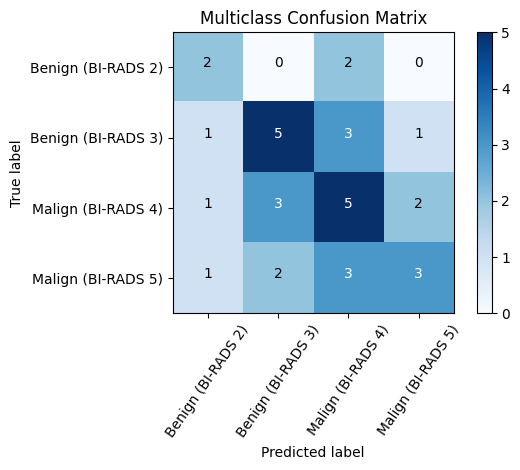

In [21]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=55)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

cm = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))

cm_plot_label =['Benign (BI-RADS 2)', 'Benign (BI-RADS 3)', 'Malign (BI-RADS 4)', 'Malign (BI-RADS 5)']
plot_confusion_matrix(cm, cm_plot_label, title ='Multiclass Confusion Matrix')

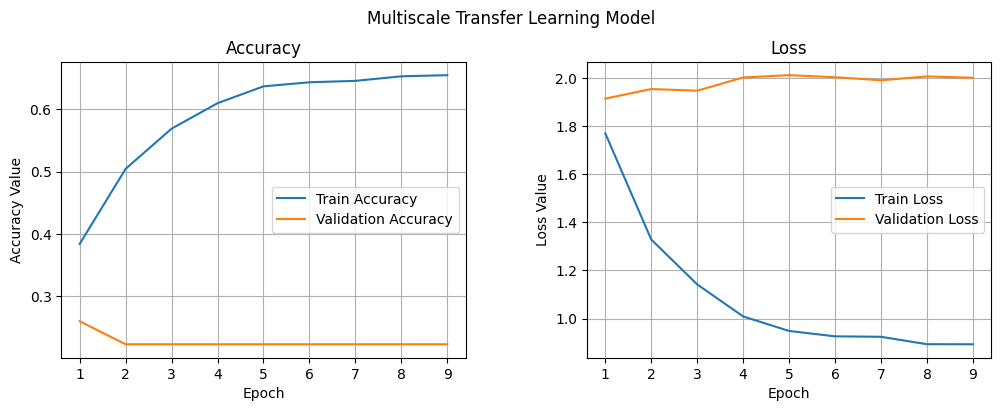

In [22]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

t = f.suptitle('Multiscale Transfer Learning Model', fontsize=12)

f.subplots_adjust(top=0.85, wspace=0.3)

# Dynamic epoch count
epoch_list = range(1, len(history.history['accuracy']) + 1)

# Accuracy Plot
ax1.plot(epoch_list, history.history['accuracy'], label='Train Accuracy')
ax1.plot(epoch_list, history.history['val_accuracy'], label='Validation Accuracy')

ax1.grid()
ax1.set_ylabel('Accuracy Value')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
ax1.legend(loc="best")

# Loss Plot
ax2.plot(epoch_list, history.history['loss'], label='Train Loss')
ax2.plot(epoch_list, history.history['val_loss'], label='Validation Loss')

ax2.grid()
ax2.set_ylabel('Loss Value')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
ax2.legend(loc="best")

plt.show()

In [23]:
print("y_test:", y_test.shape)
print("y_pred:", y_pred.shape)

y_test: (34, 4)
y_pred: (34, 4)


In [24]:
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    mean_absolute_error,
    mean_squared_error,
    cohen_kappa_score
)
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
# Predictions
pred = model.predict(x_test)
y_pred = np.argmax(pred, axis=1)
y_test = np.argmax(y_test, axis=1)

# Target labels
target_names = [
    'Benign (BI-RADS 2)',
    'Benign (BI-RADS 3)',
    'Malign (BI-RADS 4)',
    'Malign (BI-RADS 5)'
]

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Additional Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

# Print all metrics
print("\nAdditional Evaluation Metrics:")
print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1-score       : {f1:.4f}")
print(f"MCC            : {mcc:.4f}")
print(f"MAE            : {mae:.4f}")
print(f"MSE            : {mse:.4f}")
print(f"Cohen's Kappa  : {kappa:.4f}")

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step

2026-07-27 07:56:54.431366: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step 
Classification Report:
                    precision    recall  f1-score   support

Benign (BI-RADS 2)       0.40      0.50      0.44         4
Benign (BI-RADS 3)       0.50      0.50      0.50        10
Malign (BI-RADS 4)       0.38      0.45      0.42        11
Malign (BI-RADS 5)       0.50      0.33      0.40         9

          accuracy                           0.44        34
         macro avg       0.45      0.45      0.44        34
      weighted avg       0.45      0.44      0.44        34

Confusion Matrix:
[[2 0 2 0]
 [1 5 3 1]
 [1 3 5 2]
 [1 2 3 3]]

Additional Evaluation Metrics:
Accuracy       : 0.4412
Precision      : 0.4509
Recall         : 0.4412
F1-score       : 0.4400
MCC            : 0.2320
MAE            : 0.7941
MSE            : 1.3235
Cohen's Kappa  : 0.2300


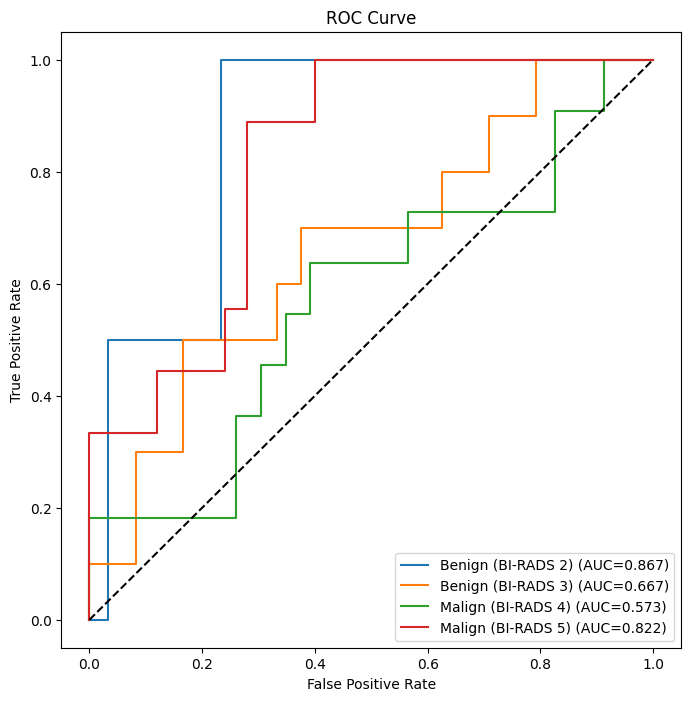

In [25]:
import matplotlib.pyplot as plt
n_classes = len(target_names)
y_test_bin = label_binarize(y_test, classes=range(n_classes))
plt.figure(figsize=(8,8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i],pred[:,i])
    roc_auc = auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f"{target_names[i]} (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [26]:
macro_auc = roc_auc_score(y_test_bin,pred,multi_class='ovr',average='macro')
weighted_auc = roc_auc_score(y_test_bin,pred,multi_class='ovr',average='weighted')
print(f"\nMacro AUC     : {macro_auc:.4f}")
print(f"Weighted AUC  : {weighted_auc:.4f}")


Macro AUC     : 0.7322
Weighted AUC  : 0.7011
